# Supplementary Figure 12: sensitivity to uniform and random initialization

Panel a uses an equal-weight starting composition. Panel b uses five independent random starting compositions with state weights sampled from Uniform(0,1), using seeds 0–4. Every starting vector is normalized to total post-passage abundance $1/30{,}000$. Each run is independently iterated to periodic convergence.


In [3]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Supplementary_Figure_12_outputs")
PCN_CAPACITY_GRID=(np.array([100],dtype=int) if RUN_MODE=="quick" else np.arange(20,101,5,dtype=int))
CONDITIONS=("transposition on","transposition off")
RANDOM_SEEDS=tuple(range(5))


## Converged sensitivity sweep


In [5]:
rows=[]
for max_pcn in PCN_CAPACITY_GRID:
    configs={c.condition:c for c in standard_configurations(int(max_pcn))}
    for condition in CONDITIONS:
        r=evaluate_configuration(int(max_pcn),configs[condition],initial_state=uniform_initial_state(int(max_pcn)))
        r.update({"initialization":"uniform","seed":np.nan}); rows.append(r)
        for seed in RANDOM_SEEDS:
            init=random_initial_state(int(max_pcn),np.random.default_rng(seed))
            r=evaluate_configuration(int(max_pcn),configs[condition],initial_state=init)
            r.update({"initialization":"random","seed":seed}); rows.append(r)
results=pd.DataFrame(rows)

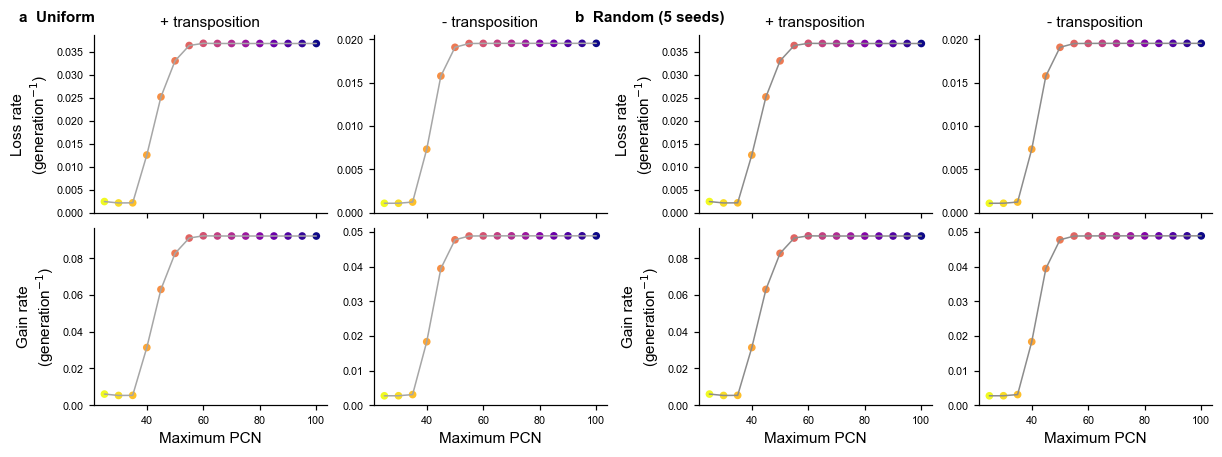

In [17]:
fig,axes=plt.subplots(2,4,figsize=(11.0,4.0),sharex='col',constrained_layout=True)
for group,init_type in enumerate(("uniform","random")):
    for col_in_group,condition in enumerate(CONDITIONS):
        col=group*2+col_in_group
        for row,(metric,phase) in enumerate((("loss_rate","loss"),("gain_rate","gain"))):
            ax=axes[row,col]
            if init_type=="uniform":
                d=results[(results.initialization=="uniform")&(results.condition==condition)&results.response_valid].sort_values("maximum_PCN")
                ax.plot(d.maximum_PCN,d[metric],color="0.65",lw=1)
                ax.scatter(d.maximum_PCN,d[metric],c=d.maximum_PCN,cmap="plasma_r",s=16)
            else:
                d=results[(results.initialization=="random")&(results.condition==condition)&results.response_valid]
                s=d.groupby("maximum_PCN")[metric].agg(["mean","min","max"]).reset_index().sort_values("maximum_PCN")
                ax.fill_between(s.maximum_PCN,s["min"],s["max"],color="0.85",lw=0)
                ax.plot(s.maximum_PCN,s["mean"],color="0.55",lw=1)
                ax.scatter(s.maximum_PCN,s["mean"],c=s.maximum_PCN,cmap="plasma_r",s=16)
            ax.set_ylim(bottom=0)
            if row==1: ax.set_xlabel("Maximum PCN", fontsize = 10)
            if col in (0,2): ax.set_ylabel(f"{phase.capitalize()} rate\n(generation$^{{-1}}$)", fontsize = 10)
            if row==0: ax.set_title("+ transposition" if condition=="transposition on" else "- transposition", fontsize = 10)
fig.text(0.01,1,"a  Uniform",fontweight="bold",va="top", fontsize = 10)
fig.text(0.47,1,"b  Random (5 seeds)",fontweight="bold",va="top", fontsize = 10)
save_figure(fig,"Supplementary_Figure_12_uniform_random_initialization",FIGURE_DIR); plt.show()

export_table(results,"Supplementary_Figure_12_source_data.csv",SOURCE_DIR)
meta=core_metadata("Supplementary Figure 12"); meta["random_seeds"]="0,1,2,3,4"
export_table(meta,"Supplementary_Figure_12_run_metadata.csv",SOURCE_DIR)
